In [1]:
import re
from pathlib import Path
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
})

MODEL_LABELS = {
    "vanilla_l1": "Vanilla L1",
    "elastic_net": "Elastic Net",
    "adaptive_lasso": "Adaptive Lasso",
    "adaptive_elastic_net": "AEN",
    "topk_baseline": "TopK",
}
COLORS = {
    'TopK': '#9467bd', 
    'Vanilla L1': '#d62728', 
    'Elastic Net': '#ff7f0e', 
    'Adaptive Lasso': '#1f77b4', 
    'AEN': '#2ca02c'
}
MARKERS = {
    'TopK': 'o',
    'Vanilla L1': 's',
    'Elastic Net': 'D',
    'Adaptive Lasso': '^',
    'AEN': 'v'
}
models_to_plot = ['TopK', 'Vanilla L1', 'Elastic Net', 'Adaptive Lasso', 'AEN']

## Spiked Model

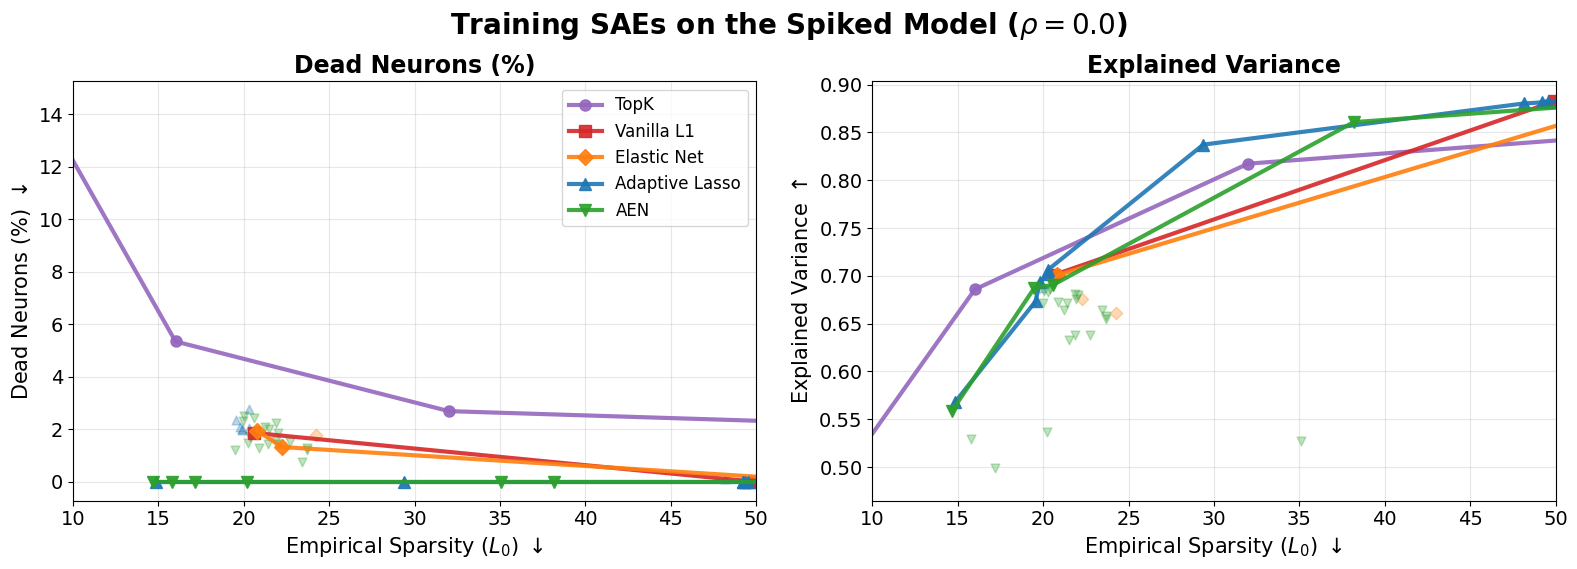

In [2]:
df_step = pd.read_csv("spiked_step_by_step_history.csv")

def extract_info(run_name):
    match = re.search(r'rho([\d\.]+)-(.*)_sweep', run_name)
    if match:
        return float(match.group(1)), match.group(2)
    return None, None

df_step[['rho', 'model_family']] = df_step['run_name'].apply(lambda x: pd.Series(extract_info(x)))

df_step["model_label"] = df_step["model_family"].map(MODEL_LABELS).fillna(df_step["model_family"])

# Average over last 10 steps to smooth online estimates
last_10 = df_step.sort_values(['run_name', 'step']).groupby('run_name').tail(10)
numeric_cols = last_10.select_dtypes(include=np.number).columns.tolist()
grouped_runs = last_10.groupby('run_name')[numeric_cols].mean().reset_index()

# Re-attach labels
grouped_runs[['rho', 'model_family']] = grouped_runs['run_name'].apply(lambda x: pd.Series(extract_info(x)))
grouped_runs["model_label"] = grouped_runs["model_family"].map(MODEL_LABELS).fillna(grouped_runs["model_family"])

# 3. TRUNCATE to L0 >= 8 and <= 64 for rho = 0.0 ONLY
filtered_runs = grouped_runs[(grouped_runs['l0_active_features'] >= 7.5) & 
                             (grouped_runs['l0_active_features'] <= 64.5) & 
                             (grouped_runs['rho'] == 0.0)].copy()

# 4. Pareto Frontier Logic
def get_pareto_frontier(Xs, Ys, maxX=False, maxY=True):
    if len(Xs) == 0:
        return np.array([])
    sorted_list = sorted([[Xs[i], Ys[i]] for i in range(len(Xs))], reverse=maxX)
    pareto_front = [sorted_list[0]]
    for pair in sorted_list[1:]:
        if maxY:
            if pair[1] >= pareto_front[-1][1]:
                pareto_front.append(pair)
        else:
            if pair[1] <= pareto_front[-1][1]:
                pareto_front.append(pair)
    return np.array(pareto_front)

# 5. Plotting a 1x2 grid just for rho = 0.0
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.rcParams.update({"font.family": "sans-serif", "font.size": 14})

metrics = [
    ("dead_neurons_pct", r"Dead Neurons (%) $\downarrow$", False), 
    ("explained_variance", r"Explained Variance $\uparrow$", True),
]


for col, (metric_col, y_label, maximize_y) in enumerate(metrics):
    ax = axes[col]
    
    for model in models_to_plot:
        sub = filtered_runs[filtered_runs['model_label'] == model].dropna(subset=[metric_col, 'l0_active_features'])
        if sub.empty: continue
            
        # Plot all points as a scatter (transparent)
        ax.scatter(
            sub['l0_active_features'],
            sub[metric_col],
            color=COLORS.get(model),
            alpha=0.3,
            s=40,
            marker=MARKERS.get(model, 'o'),
        )
        
        # Get and plot Pareto frontier (solid line)
        pf = get_pareto_frontier(sub['l0_active_features'].values, sub[metric_col].values, maxX=False, maxY=maximize_y)
        if len(pf) > 0:
            ax.plot(
                pf[:, 0],
                pf[:, 1],
                label=model,
                color=COLORS.get(model),
                linewidth=3,
                alpha=0.9,
                marker=MARKERS.get(model, 'o'),
                markersize=8,
            )
    
    ax.set_xlabel(r"Empirical Sparsity ($L_0$) $\downarrow$", fontsize=15)
    ax.set_ylabel(y_label, fontsize=15)
    ax.set_title(y_label.split('$')[0].strip(), fontweight='bold', fontsize=17)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(10, 50)  # Lock x-axis strictly around the oracle sparsity (s=16)

axes[0].legend(frameon=True, loc='best', fontsize=12)

plt.suptitle(r"Training SAEs on the Spiked Model ($\rho=0.0$)", fontsize=20, fontweight='bold', y=0.95)
plt.tight_layout()

## Pythia 70M Pareto Frontier

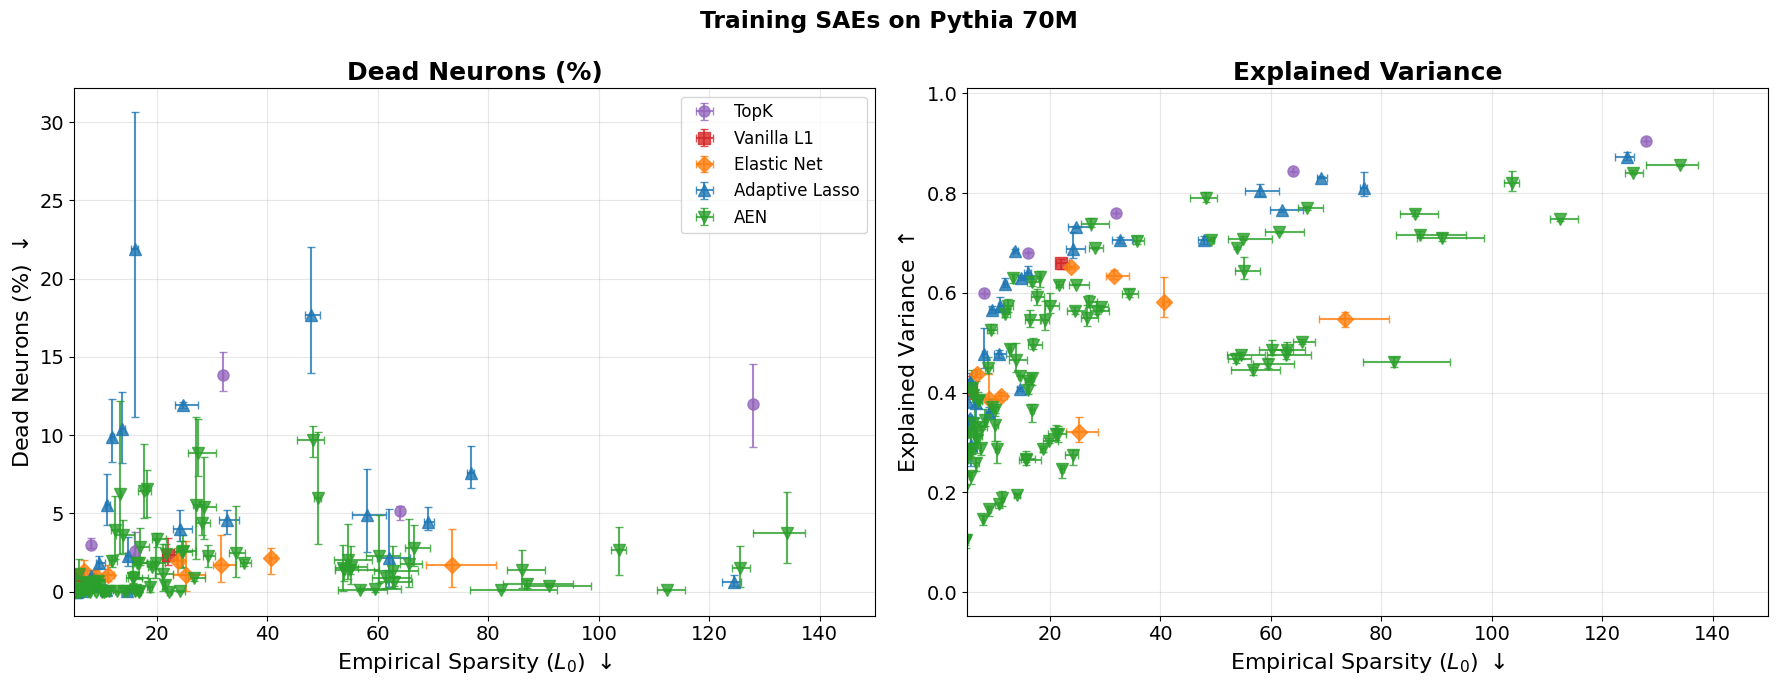

In [3]:
df_step = pd.read_csv("pythia70m_step_by_step_history.csv")

def extract_info(run_name):
    match = re.search(r'llm-(.*)-seed(\d+)', str(run_name))
    if match: return match.group(1).split('_sweep')[0], int(match.group(2))
    return "unknown", 0

df_step[['model_family', 'seed']] = df_step['run_name'].apply(lambda x: pd.Series(extract_info(x)))
df_step["model_label"] = df_step["model_family"].map(MODEL_LABELS).fillna(df_step["model_family"])

# Average the last 10 logging steps of each run to reduce terminal noise
last_10 = df_step.sort_values(['run_name', 'step']).groupby('run_name').tail(10)
numeric_cols = last_10.select_dtypes(include=np.number).columns.tolist()
grouped_runs = last_10.groupby('run_name')[numeric_cols].mean().reset_index()

grouped_runs[['model_family', 'seed']] = grouped_runs['run_name'].apply(lambda x: pd.Series(extract_info(x)))
grouped_runs["model_label"] = grouped_runs["model_family"].map(MODEL_LABELS).fillna(grouped_runs["model_family"])

# Plotting Pareto with [min, max] bounds
def plot_pythia_pareto_with_minmax(df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    metrics = [("dead_neurons_pct_window", r"Dead Neurons (%) $\downarrow$"), ("explained_variance", r"Explained Variance $\uparrow$")]

    for i, (metric_col, y_label) in enumerate(metrics):
        ax = axes[i]
        for model in models_to_plot:
            sub = df[df['model_label'] == model].copy()
            if sub.empty: continue
            
            sub['sweep_id'] = sub['run_name'].apply(lambda x: x.split('-seed')[0])
            agg = sub.groupby('sweep_id').agg({
                'l0_active_features': ['mean', 'min', 'max'],
                metric_col: ['mean', 'min', 'max']
            }).reset_index()
            
            # [Min, Max] Asymmetric Spread across seeds
            x_err = np.vstack([
                agg['l0_active_features']['mean'] - agg['l0_active_features']['min'],
                agg['l0_active_features']['max'] - agg['l0_active_features']['mean']
            ])
            y_err = np.vstack([
                agg[metric_col]['mean'] - agg[metric_col]['min'],
                agg[metric_col]['max'] - agg[metric_col]['mean']
            ])
            
            ax.errorbar(agg['l0_active_features']['mean'], agg[metric_col]['mean'], 
                        xerr=x_err, yerr=y_err, 
                        fmt=MARKERS[model], color=COLORS[model], label=model if i==0 else "",
                        capsize=3, alpha=0.8, markersize=8, elinewidth=1.5)

        ax.set_xlabel(r"Empirical Sparsity ($L_0$) $\downarrow$")
        ax.set_ylabel(y_label)
        ax.set_title(y_label.split('$')[0].strip(), fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(5, 150)

    axes[0].legend(frameon=True, loc='best', fontsize=12)
    plt.suptitle("Training SAEs on Pythia 70M", fontweight='bold', y=0.98)
    plt.tight_layout()

plot_pythia_pareto_with_minmax(grouped_runs)

## Pythia 70M Training Dynamics

In [4]:
# RUN CONFIGURATIONS
RUNS_K16 = {
    'AEN': 'llm-adaptive_elastic_net_sweep087',
    'Adaptive Lasso': 'llm-adaptive_lasso_sweep031',
    'Elastic Net': 'llm-elastic_net_sweep001',
    'TopK': 'llm-topk_baseline_sweep001'
}

RUNS_K32 = {
    'AEN': 'llm-adaptive_elastic_net_sweep063',
    'Adaptive Lasso': 'llm-adaptive_lasso_sweep025',
    'Elastic Net': 'llm-elastic_net_sweep006',
    'TopK': 'llm-topk_baseline_sweep002'
}

RUNS_K128 = {
    'AEN': 'llm-adaptive_elastic_net_sweep136',
    'Adaptive Lasso': 'llm-adaptive_lasso_sweep027',
    'Elastic Net': 'llm-elastic_net_sweep004',
    'TopK': 'llm-topk_baseline_sweep004'
}

# METRICS
EXPLORATORY_METRICS = [
    # Row 1: Feature Utilization
    ('dead_features_pct_batch', 'Dead Neurons (%)'),
    ('feature_utilization_batch/normalized_entropy', 'Normalized Entropy (Uniformity)'),
    ('feature_utilization_batch/gini', 'Gini Coefficient (Inequality)'),
    ('feature_utilization_batch/top10pct_mass_pct', 'Top 10% Activation Mass (%)'),
    
    # Row 2: Coherence
    ('dictionary_coherence_nn/p10', 'p10 Pairwise Coherence'),
    ('dictionary_coherence_nn/p50', 'p50 Pairwise Coherence'),
    ('dictionary_coherence_nn/p90', 'p90 Pairwise Coherence'),
    ('dictionary_coherence_nn_max', 'Max Pairwise Coherence'),
    
    # Row 3: Performance & Mechanisms
    ('explained_variance', 'Explained Variance'),
    ('loss_recon', 'Reconstruction Loss (MSE)'),
    ('feature_shrinkage_ratio', 'Feature Shrinkage Ratio'),
    ('activation_effective_sample_size', 'Activation Effective Sample Size (ESS)'),
]


def plot_exploratory_dynamics_plt(
    df_history: pd.DataFrame, 
    run_config: dict, 
    target_l0_label: str = "32", 
    model_name: str = "Pythia 70M",
    aggregate_seeds: bool = True,
    smoothing_span: int = 20  # Param for ema (1 = no smoothing)
):
    # Extract matching runs
    matched_dfs = []
    for arch_name, prefix in run_config.items():
        sub = df_history[df_history['run_name'].astype(str).str.startswith(prefix)].copy()
        if not sub.empty:
            sub['Architecture'] = arch_name
            matched_dfs.append(sub)
            
    if not matched_dfs:
        print(f"No runs found matching configuration for L0 = {target_l0_label}")
        return

    df_plot = pd.concat(matched_dfs, ignore_index=True)

    group_cols = ['Architecture', 'step']
    numeric_cols = [c for c in df_plot.select_dtypes(include=[np.number]).columns if c not in group_cols]

    if aggregate_seeds:
        # We calculate mean, min, and max for shaded error bands
        df_plot = df_plot.groupby(group_cols)[numeric_cols].agg(['mean', 'min', 'max']).reset_index()
    else:
        df_plot = df_plot.sort_values(by=group_cols)

    # Setup 3x4 figure
    fig, axes = plt.subplots(3, 4, figsize=(24, 18))
    axes = axes.flatten()

    for i, (col, title) in enumerate(EXPLORATORY_METRICS):
        ax = axes[i]
        
        # Check if column exists (handling multi-index if aggregated)
        col_exists = (col in df_plot.columns) if not aggregate_seeds else (col in df_plot.columns.levels[0])
        if not col_exists:
            ax.set_title(f"{title} (NOT FOUND)", fontsize=14)
            continue
            
        for arch in run_config.keys():
            sub = df_plot[df_plot['Architecture'] == arch]
            if sub.empty: continue
            
            steps = sub['step']
            arch_color = COLORS.get(arch, '#333')
            
            if aggregate_seeds:
                valid_mask = sub[col]['mean'].notna()
                
                if valid_mask.any():
                    valid_steps = steps[valid_mask]
                    
                    # Apply ema
                    if smoothing_span > 1:
                        mean_vals = sub[col]['mean'][valid_mask].ewm(span=smoothing_span).mean()
                        min_vals = sub[col]['min'][valid_mask].ewm(span=smoothing_span).mean()
                        max_vals = sub[col]['max'][valid_mask].ewm(span=smoothing_span).mean()
                    else:
                        mean_vals = sub[col]['mean'][valid_mask]
                        min_vals = sub[col]['min'][valid_mask]
                        max_vals = sub[col]['max'][valid_mask]
                    
                    ax.plot(valid_steps, mean_vals, label=arch, color=arch_color, linewidth=3.0)
                    ax.fill_between(valid_steps, min_vals, max_vals, color=arch_color, alpha=0.15)
            else:
                valid_mask = sub[col].notna()
                
                if valid_mask.any():
                    valid_steps = steps[valid_mask]
                    
                    # Apply ema
                    if smoothing_span > 1:
                        vals = sub[col][valid_mask].ewm(span=smoothing_span).mean()
                    else:
                        vals = sub[col][valid_mask]
                    
                    ax.plot(valid_steps, vals, label=arch, color=arch_color, linewidth=3.0, alpha=0.85)
        
        # Formatting
        ax.set_title(title, fontweight='bold', fontsize=16)
        ax.grid(True, alpha=0.3)
        if i >= 8:  # Bottom row for 3x4 grid
            ax.set_xlabel('Training Steps')
            
        # Limits cleanup
        if col == 'explained_variance':
            ax.set_ylim(0, 1.0)
        elif col == 'feature_utilization_batch/gini':
            ax.set_ylim(0.5, 1.0)
            
        if i == 0: 
            # Make the legend line visually match the plot thickness
            leg = ax.legend(frameon=True, loc='best')
            for legobj in leg.legend_handles:
                legobj.set_linewidth(3.0)

    # Title layout
    title_text = f"Training Dynamics ({model_name}, L0 ≈ {target_l0_label}"
    title_text += ", Mean ± Seed Range)" if aggregate_seeds else ")"
    plt.suptitle(title_text, fontweight='bold', fontsize=22, y=1.02)
    plt.tight_layout()
    plt.show()

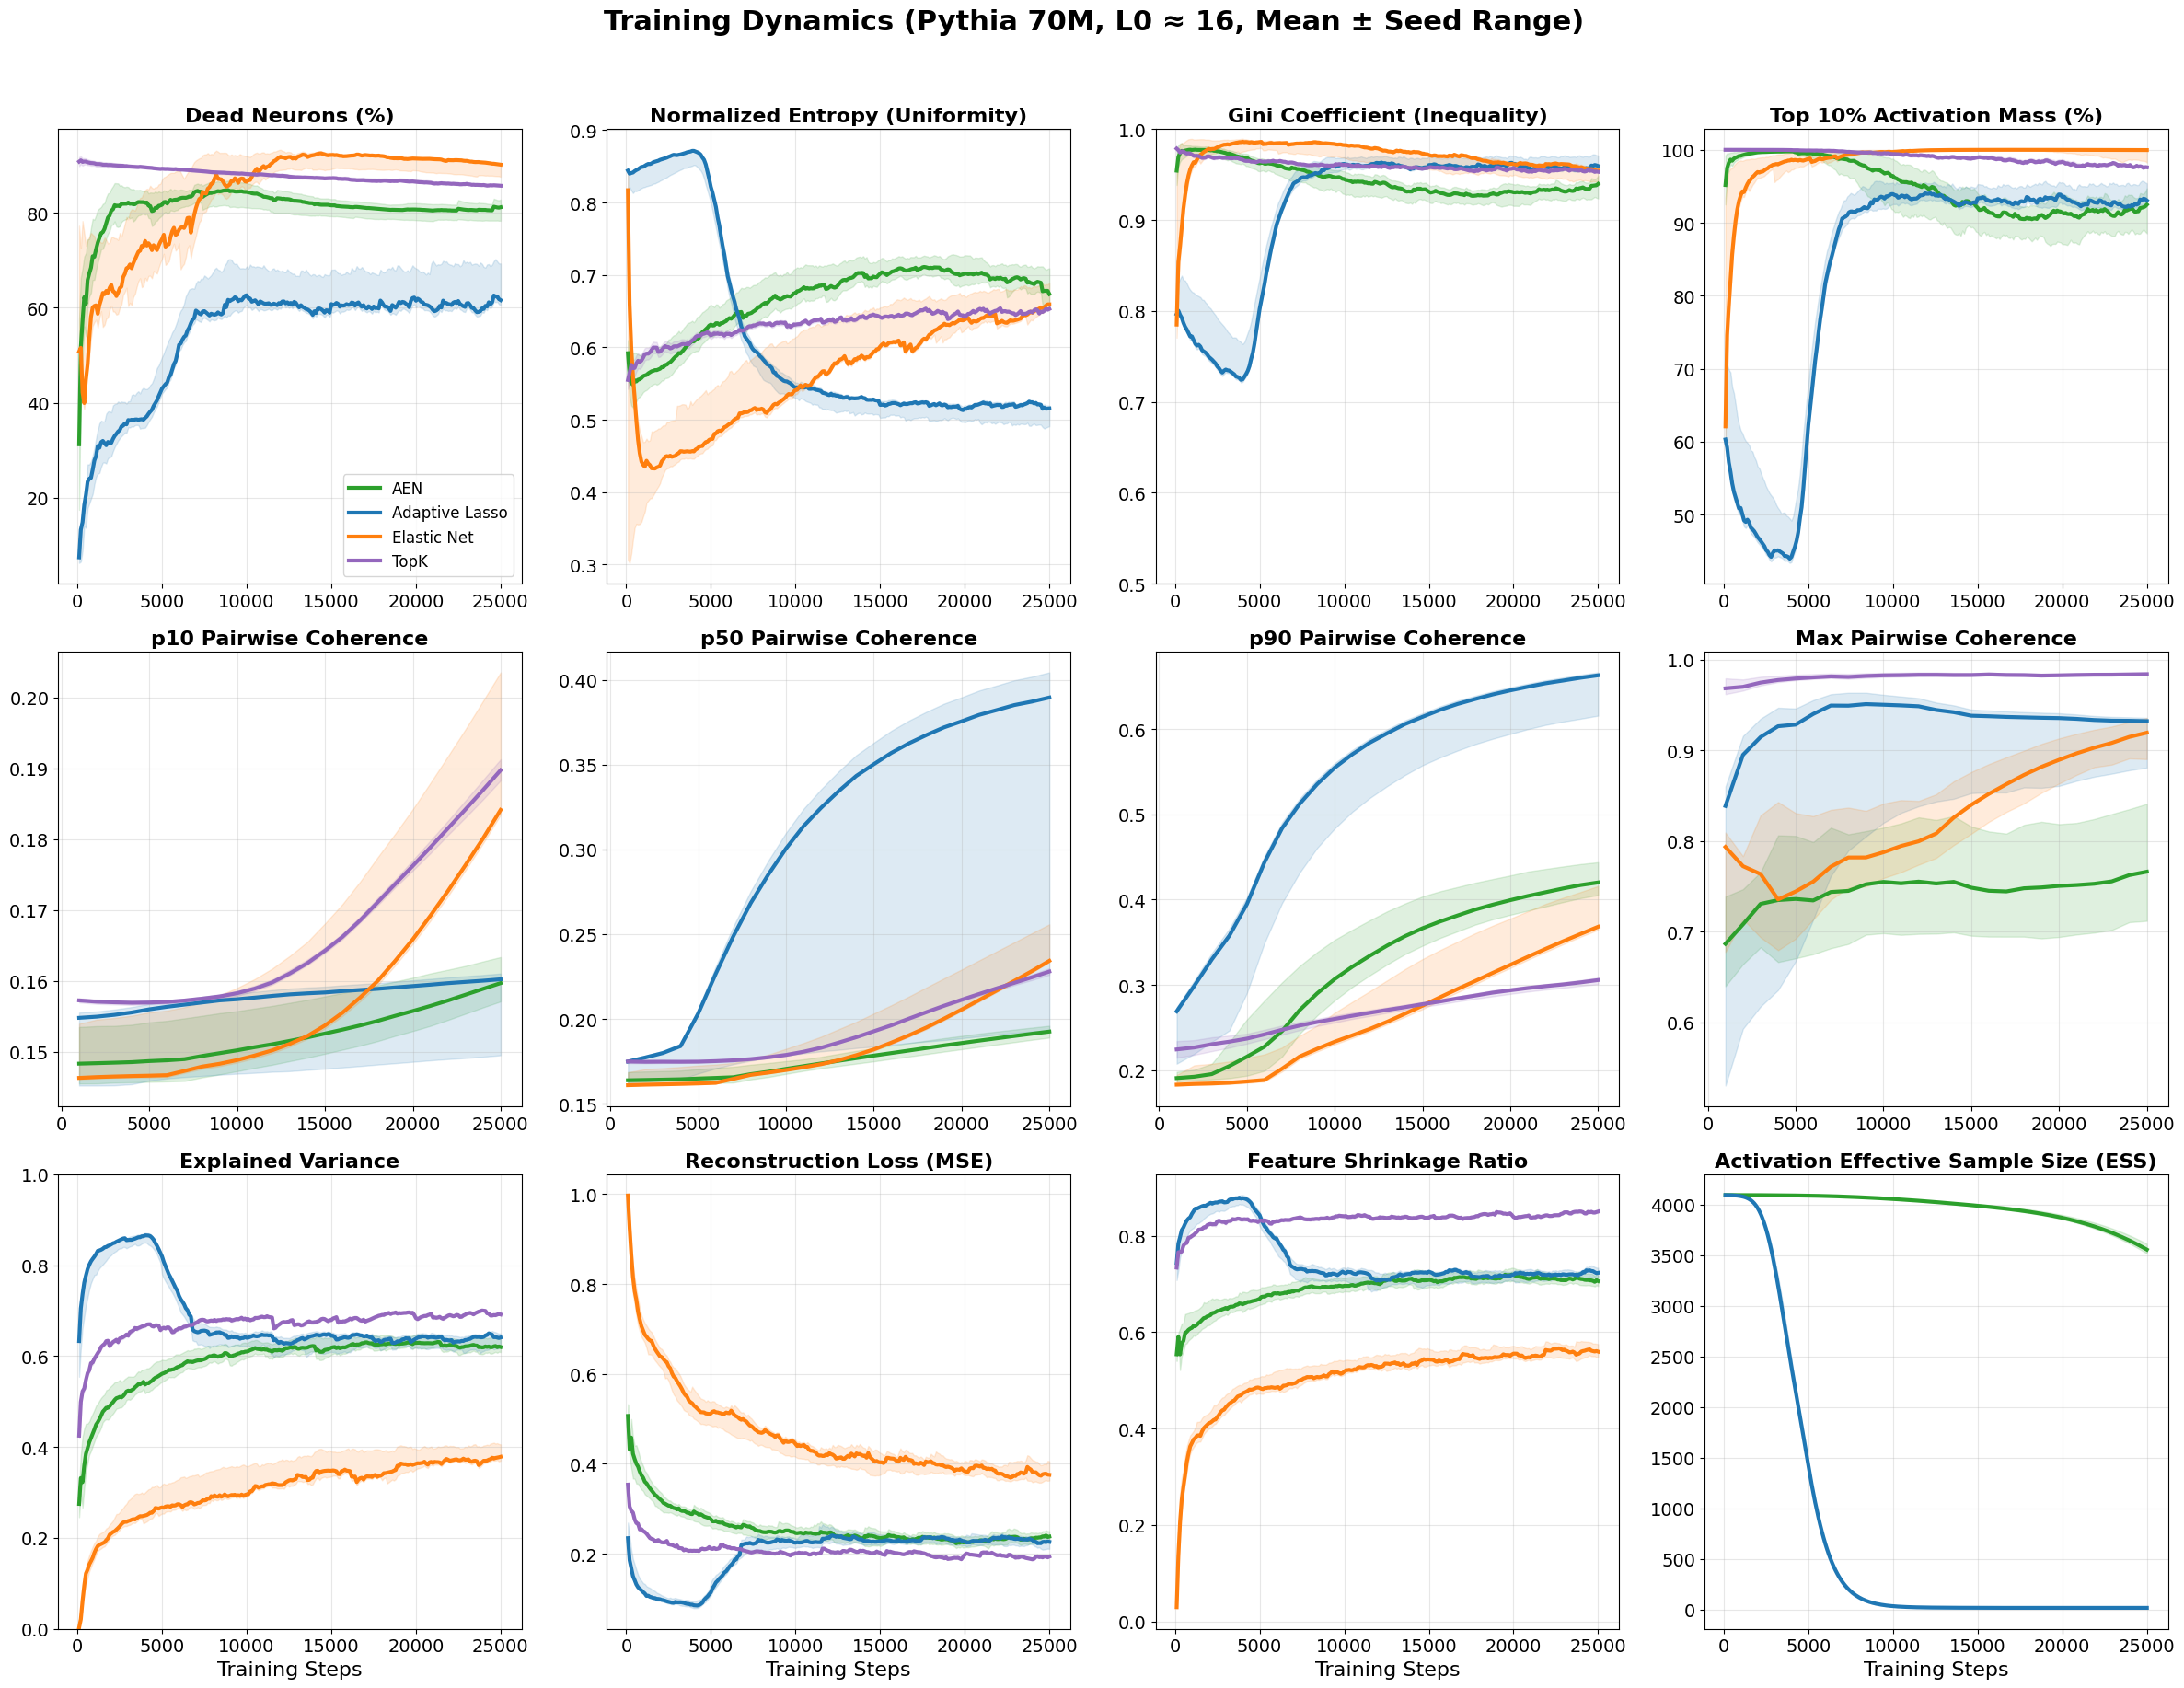

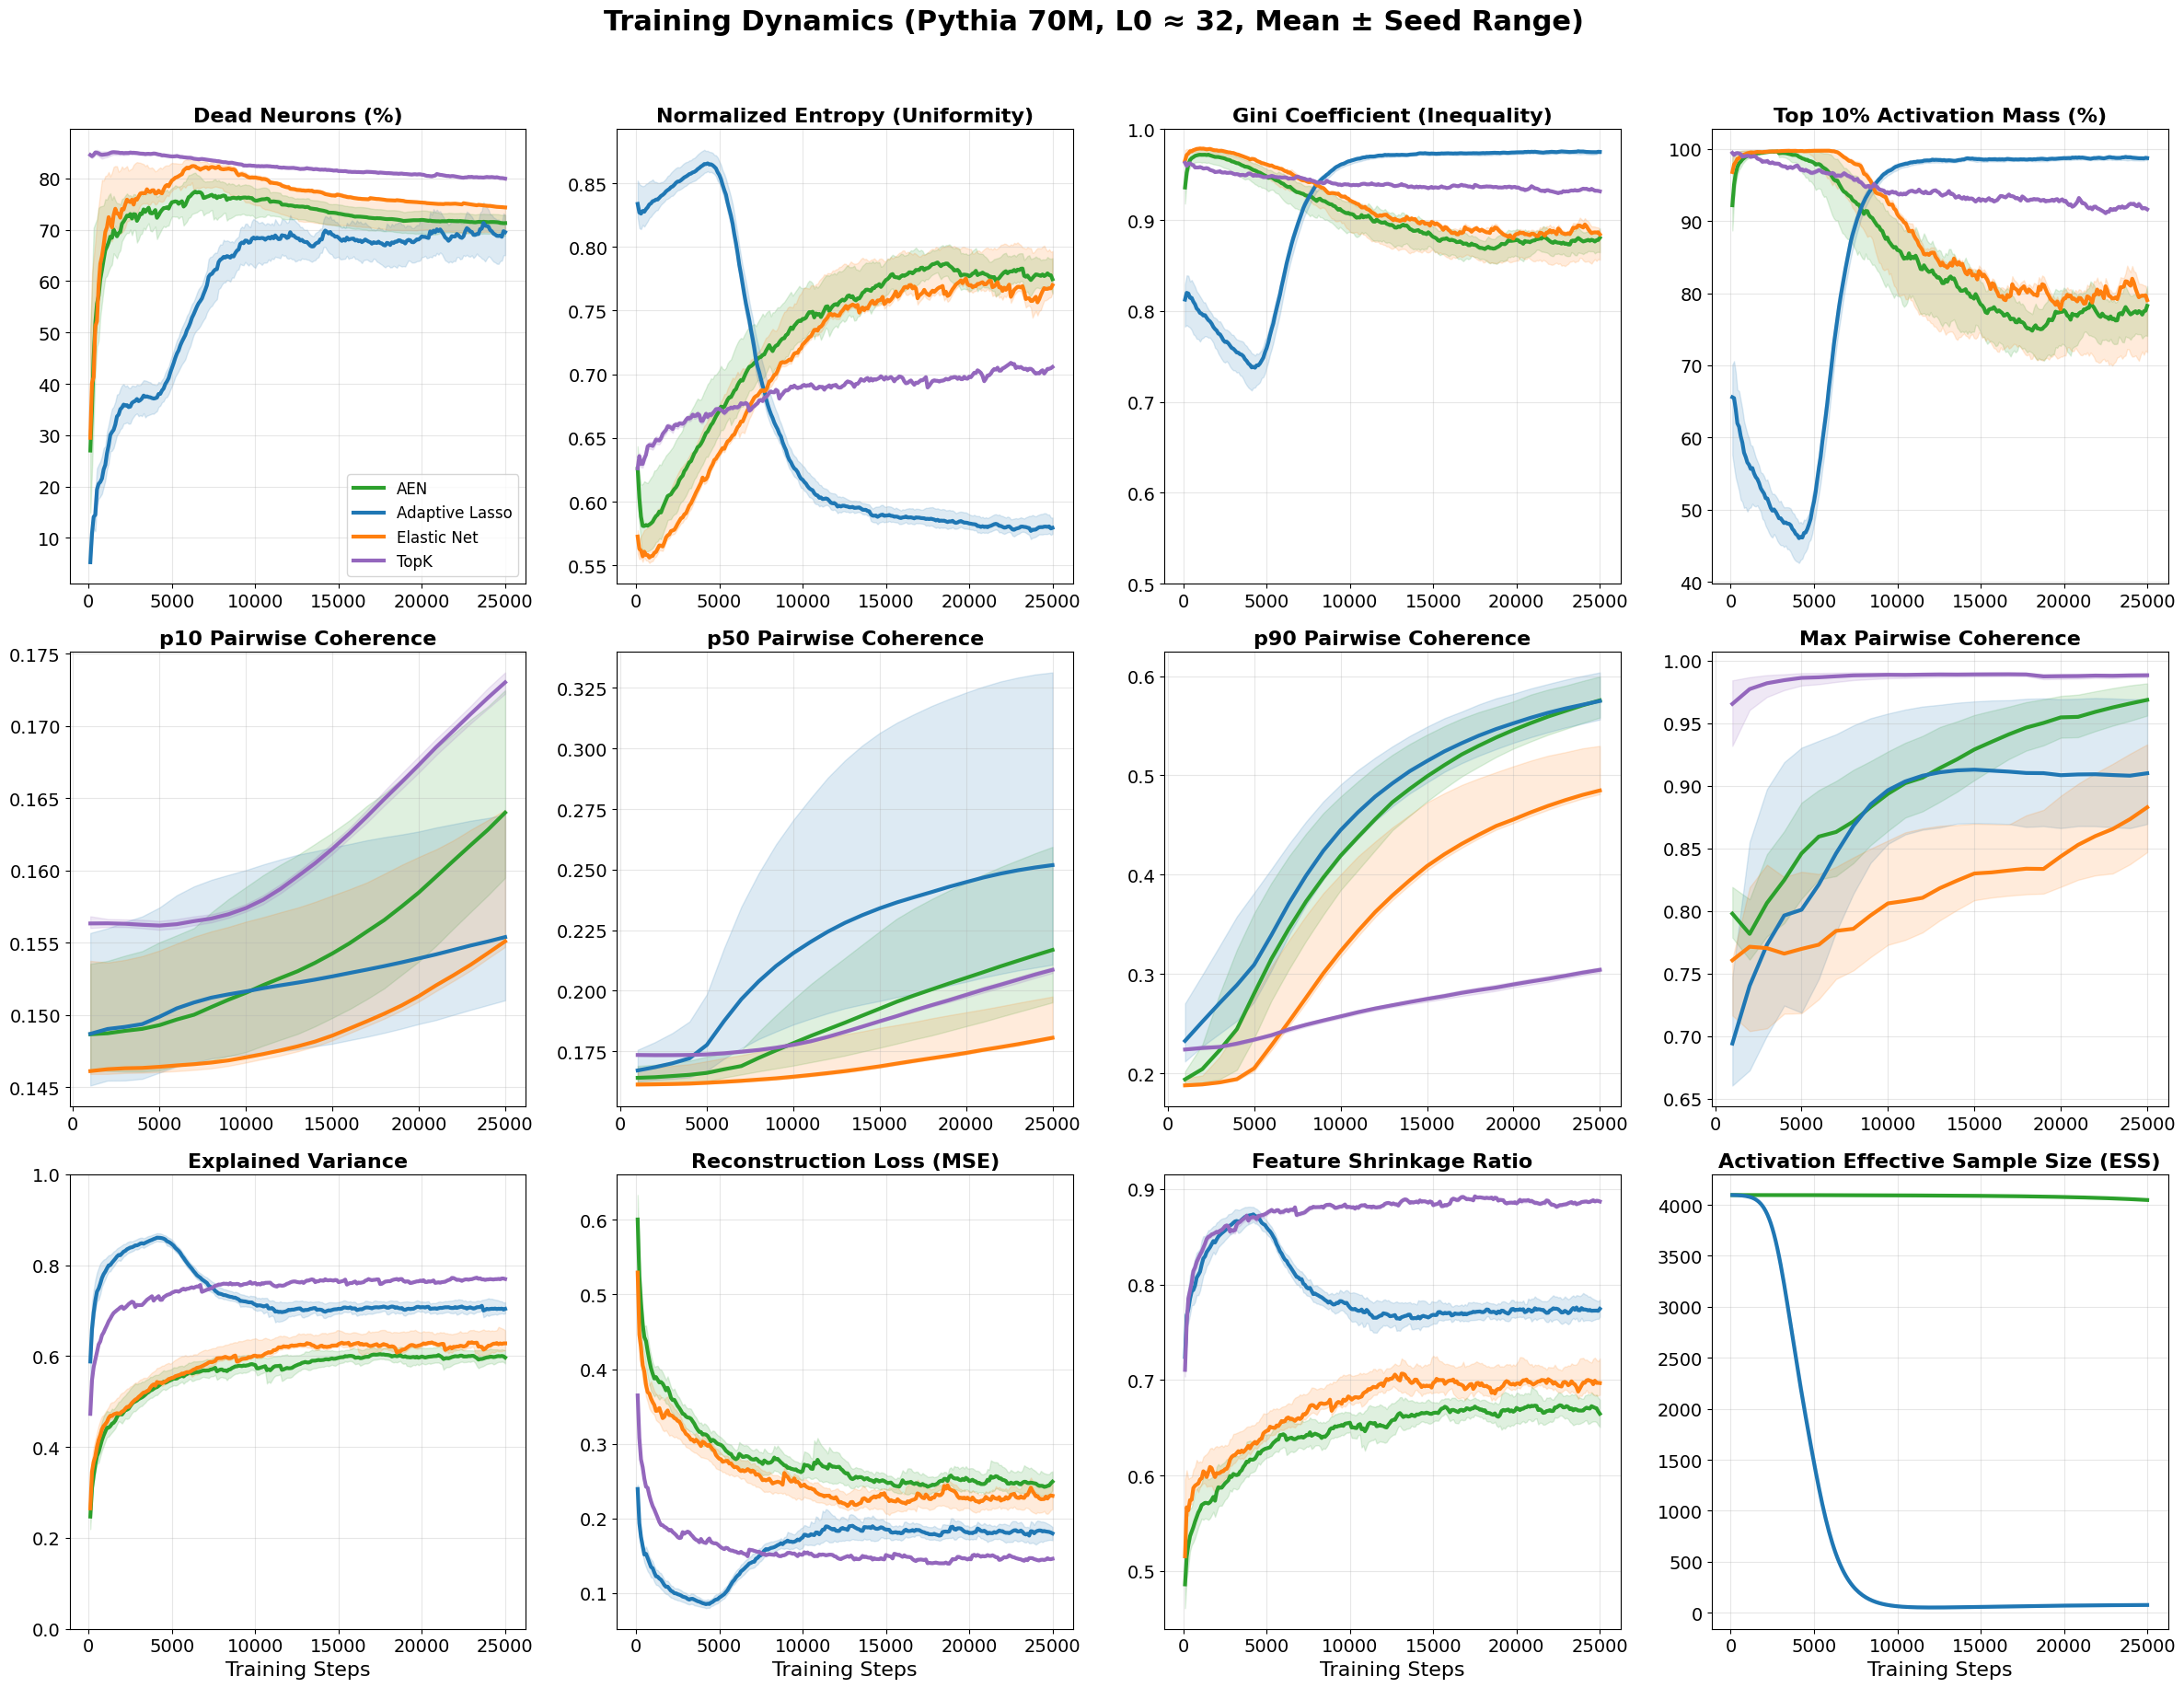

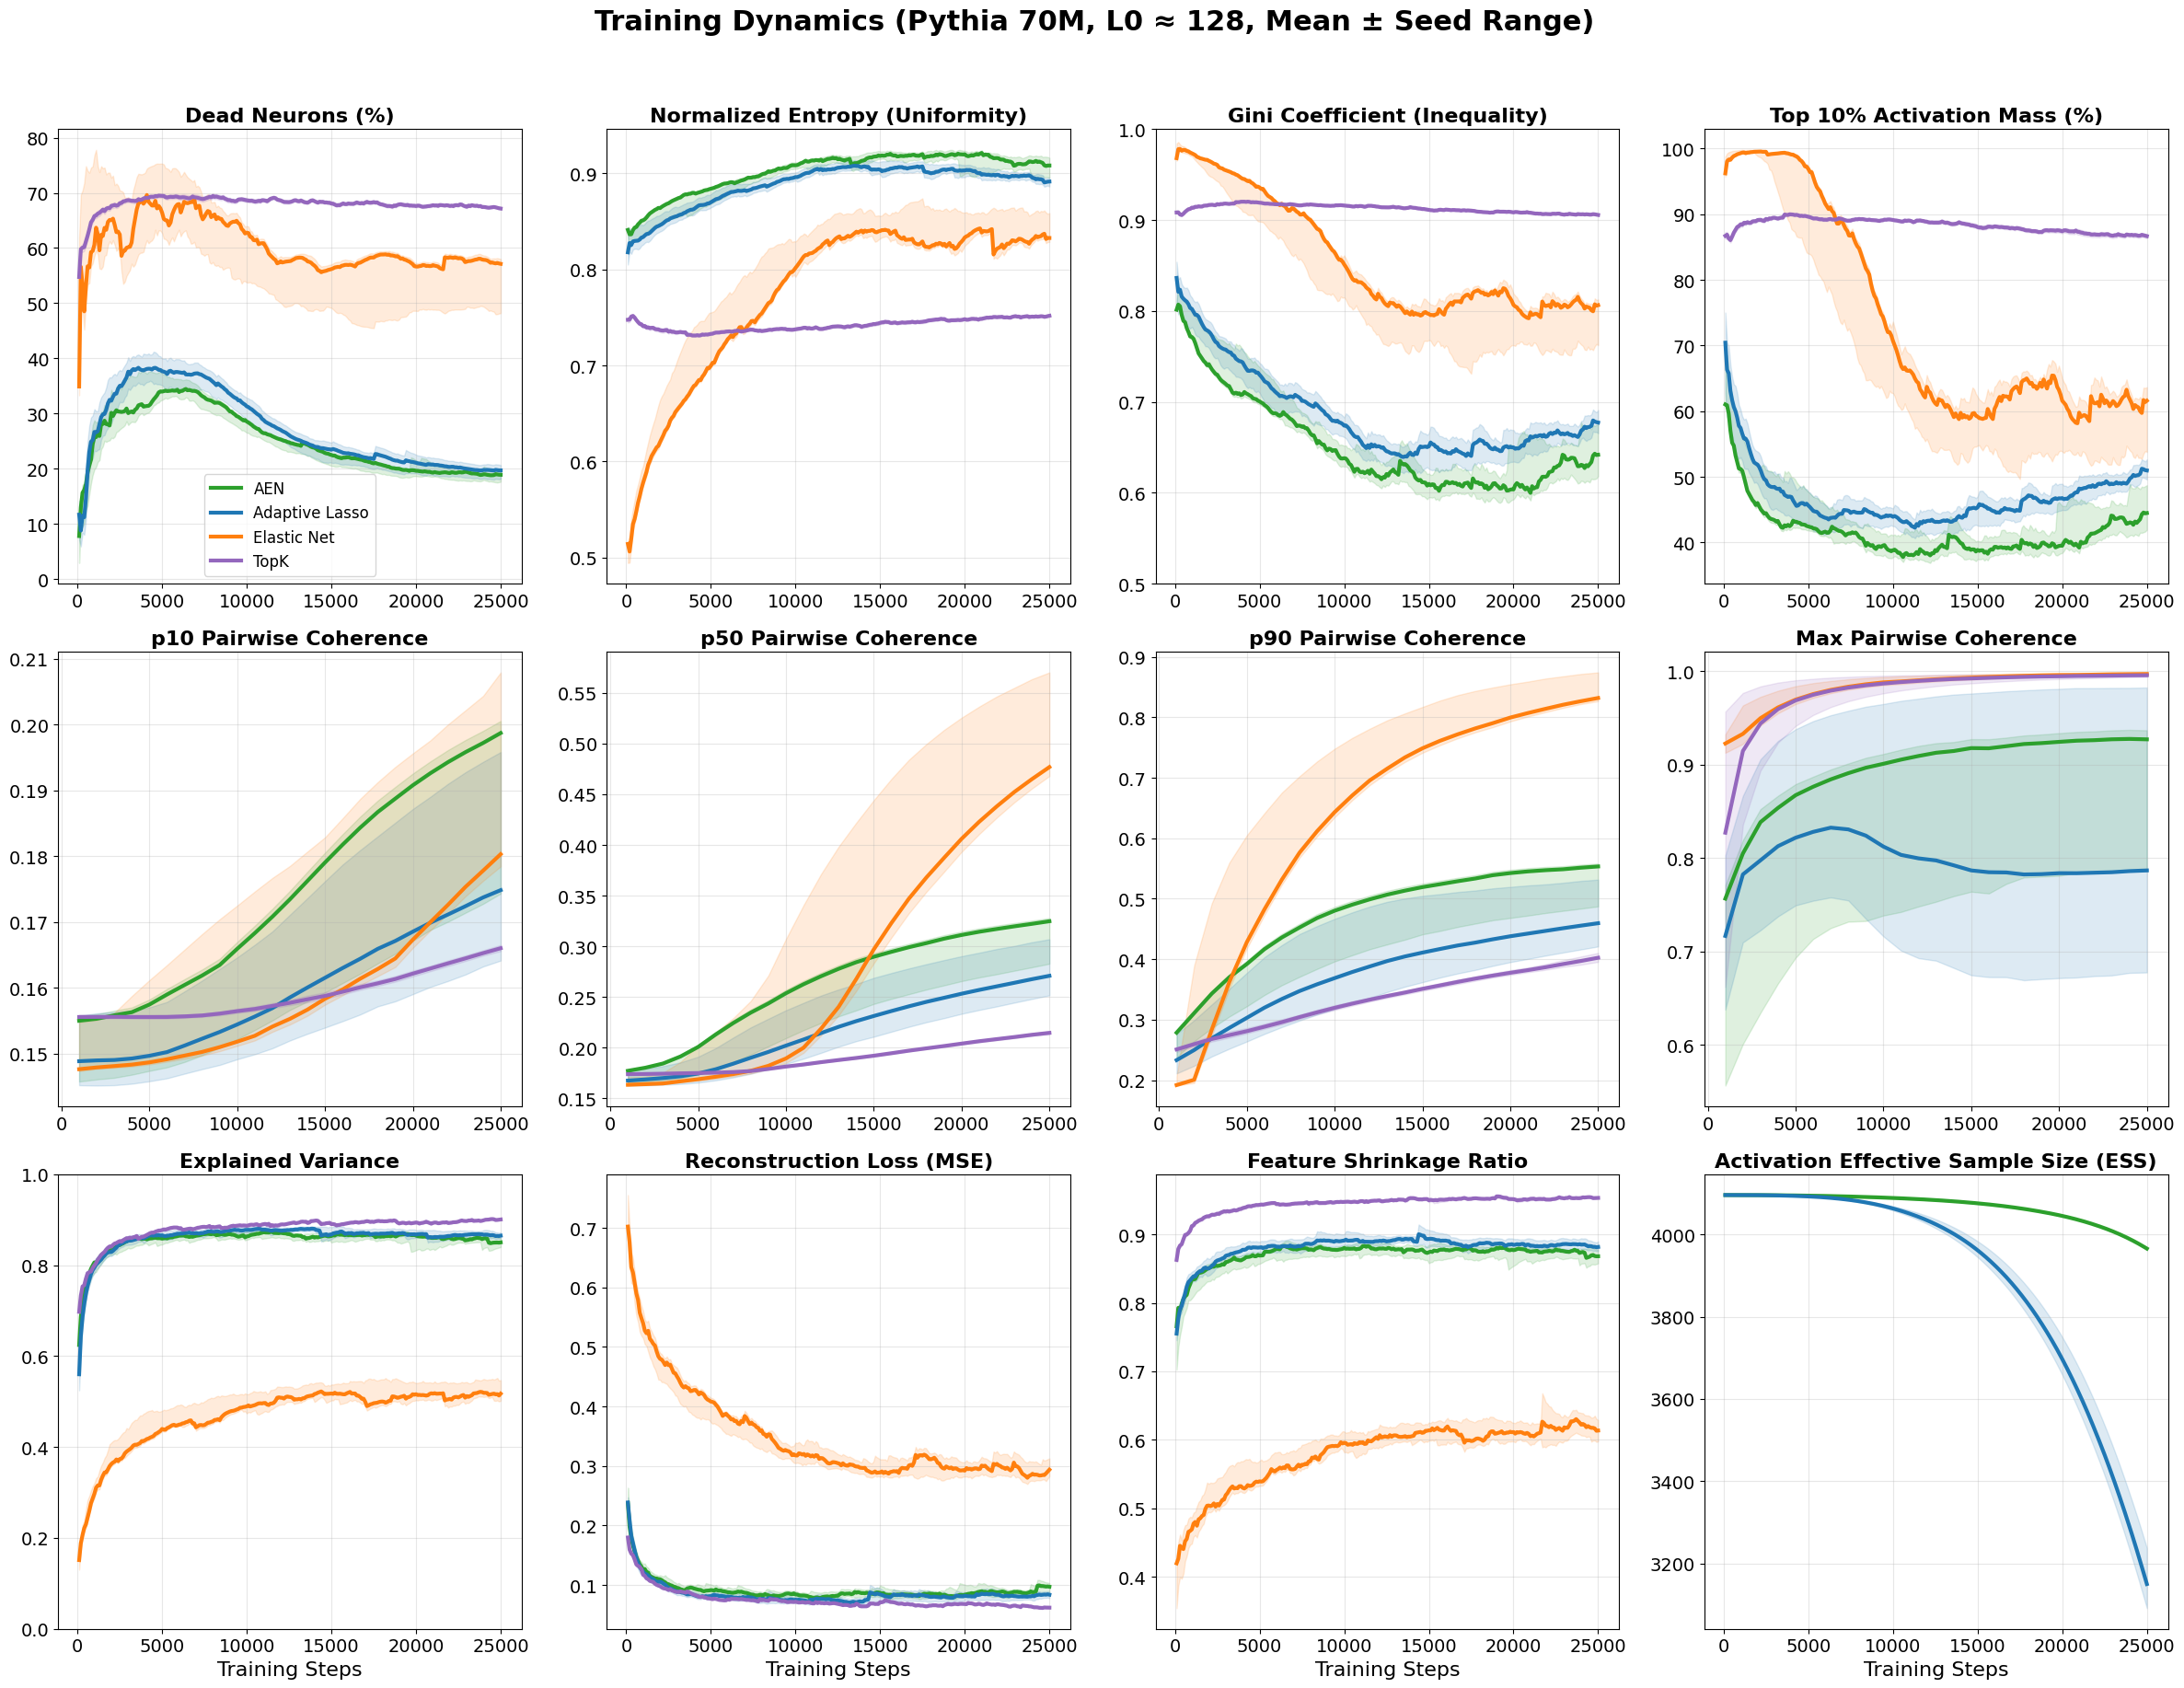

In [5]:
df_step = pd.read_csv("pythia70m_step_by_step_history.csv")

# 2. Render K = 16
plot_exploratory_dynamics_plt(df_step, RUNS_K16, target_l0_label="16")

# 3. Render K = 32
plot_exploratory_dynamics_plt(df_step, RUNS_K32, target_l0_label="32")

# 4. Render K = 128
plot_exploratory_dynamics_plt(df_step, RUNS_K128, target_l0_label="128")